In [1]:
import pandas as pd
import os
import langid
import json
from shapely.geometry import LineString
import geopandas as gpd
from shapely import wkt

os.chdir("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data")

## Reading and Cleaning

### Reviews

In [2]:
rev = pd.read_csv("reviews.csv")

In [3]:
rev = rev.drop_duplicates(subset = "review_id")

In [4]:
# Add time variables
rev['published_at_date'] = pd.to_datetime(rev['published_at_date'])

# Extract date and time (if needed)
rev['date'] = rev['published_at_date'].dt.date  # Extract just the date
rev['year'] = rev['published_at_date'].dt.year
rev['month'] = rev['published_at_date'].dt.month # Extract just the month
rev['weekday'] = rev['published_at_date'].dt.weekday

### Popular times

In [5]:
# Read data with info about locations and time
times = pd.read_csv("times.csv")
coordinates_places = times[["place_id", "coordinates"]]

# Parse the 'coordinates' column into separate latitude and longitude columns
times[['latitude', 'longitude']] = coordinates_places['coordinates'].apply(
    lambda x: pd.Series(json.loads(x))
)

# Drop the original 'coordinates' column for clarity
times = times.drop(columns='coordinates')

In [6]:
# add information about places where reviews are place and add geo info
crd = times[["place_id", "main_category", "latitude", "longitude"]]
rev = rev.merge(crd, how = "left", on = "place_id")

### Buurt

In [7]:
# Load the file with neighbourhood info
buurt = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_BUURT (1).csv", delimiter=';')[["Buurt", "Wijk", "WKT_LNG_LAT"]]


# Load the points CSV
times_gdf = gpd.GeoDataFrame(
    times,
    geometry=gpd.points_from_xy(times['longitude'], times['latitude']),
    crs="EPSG:4326"  # Ensure the correct CRS, usually WGS84
)

# Load the polygons CSV
buurt['geometry'] = buurt['WKT_LNG_LAT'].apply(wkt.loads)
buurt_gdf = gpd.GeoDataFrame(buurt, geometry='geometry', crs="EPSG:4326")

# Perform spatial join
times_gdf = gpd.sjoin(times_gdf, buurt_gdf, how="left", predicate="within")
times_gdf = times_gdf.drop(columns = ["index_right", "WKT_LNG_LAT"])
times_gdf = times_gdf[["place_id", "Buurt", "Wijk"]]

In [8]:
rev = rev.merge(times_gdf, on = "place_id", how = "left")
rev

,place_id,place_name,review_id,reviewer_profile,published_at_date,total_number_of_reviews_by_reviewer,review_translated_text,date,year,month,weekday,main_category,latitude,longitude,Buurt,Wijk
0,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChZDSUhNMG9nS0VJQ0FnSUR2dFplN0hnEAE,https://www.google.com/maps/contrib/1172831811...,2024-12-25 14:46:56,45.0,"Excelente lugar y calido servicio, mi unica qu...",2024-12-25,2024.0,12.0,2.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
1,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChZDSUhNMG9nS0VJQ0FnSUN2cmRxSERBEAE,https://www.google.com/maps/contrib/1130717941...,2024-12-18 14:46:56,1.0,NaN,2024-12-18,2024.0,12.0,2.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
2,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChdDSUhNMG9nS0VJQ0FnSURQNmN6ejNRRRAB,https://www.google.com/maps/contrib/1145475064...,2024-12-08 14:46:56,1.0,"Zondag daar geweest,wel lekker gezeten maar sc...",2024-12-08,2024.0,12.0,6.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
3,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChZDSUhNMG9nS0VJQ0FnSURQcG9xRUZnEAE,https://www.google.com/maps/contrib/1032501371...,2024-12-08 14:46:56,3.0,NaN,2024-12-08,2024.0,12.0,6.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
4,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChdDSUhNMG9nS0VJQ0FnSURQMkpMcm5nRRAB,https://www.google.com/maps/contrib/1093401749...,2024-12-08 14:46:56,55.0,Food: 1/5 | Service: 5/5 | Atmosphere: 5/5,2024-12-08,2024.0,12.0,6.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4221245,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChZDSUhNMG9nS0VJQ0FnSURRczc3cVVBEAE,https://www.google.com/maps/contrib/1002552008...,2013-01-04 22:03:29,11.0,NaN,2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten
4221246,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChdDSUhNMG9nS0VJQ0FnSUNRbUpQWHB3RRAB,https://www.google.com/maps/contrib/1104609722...,2013-01-04 22:03:29,1.0,"HABE DIE ZEIT DA GENOSSEN,UNVERGESLICH SCHON W...",2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten
4221247,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChdDSUhNMG9nS0VJQ0FnSURBNzhxUHhRRRAB,https://www.google.com/maps/contrib/1084138238...,2013-01-04 22:03:29,12.0,NaN,2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten
4221248,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChdDSUhNMG9nS0VJQ0FnSUNnd3IybjNRRRAB,https://www.google.com/maps/contrib/1118869897...,2013-01-04 22:03:30,58.0,NaN,2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten


In [9]:
rev = rev[["place_id", "place_name", "reviewer_profile", "main_category", "latitude", "longitude", "Buurt", "Wijk", "year", "month"]]

In [10]:
reviews_per_year = rev.groupby('year').size().reset_index(name='count')
reviews_per_year

,year,count
0,2006.0,6
1,2008.0,2
2,2009.0,4
3,2010.0,11
4,2011.0,192
5,2012.0,862
6,2013.0,1623
7,2014.0,4140
8,2015.0,7028
9,2016.0,19283


In [11]:
review_counts = rev['reviewer_profile'].value_counts()

# Filter for profiles with more than one review
profiles_with_multiple_reviews = review_counts[review_counts > 1].index

# Filter the original dataframe to keep only profiles with multiple reviews
rev = rev[rev['reviewer_profile'].isin(profiles_with_multiple_reviews)]

In [12]:
kkkk = times[["place_id", "name"]]
kkkk

,place_id,name
0,ChIJFTdsYMMJxkcRryoUM7EyJY0,Nooch
1,ChIJz09EBcMJxkcRwRi15EQTPog,Restaurant de Struisvogel
2,ChIJIYdU8sMJxkcRD1Ys8SczZTE,Lotti's
3,ChIJMZGUGcMJxkcRPRyYTICSTYM,Restaurant 't Zwaantje
4,ChIJy3zD9cIJxkcRxfIlpjk47JQ,Bar Brasserie OCCO
...,...,...
7325,ChIJPcEtxHEKxkcRx84qVvhT_uE,Cityden Zuidas
7326,ChIJVWZIVwsKxkcR4vauw0vYxuk,"Holiday Inn Express Amsterdam - South, an IHG ..."
7327,ChIJC_KvV9jhxUcRgDzDAbDHkBw,Amsterdam Forest Hotel
7328,ChIJN8RMMqgLxkcRknxrSHEle1E,Aparthotel Adagio Amsterdam City South


In [13]:
cnt = rev[rev["year"] == 2024]
cnt = cnt["place_id"].value_counts().reset_index()
cnt = pd.DataFrame(cnt)
cnt = cnt.rename(columns = {"index":"place_id", "place_id":"reviews 2024"})
cnt["rev_prc"] = cnt["reviews 2024"]/cnt["reviews 2024"].max()
cnt = cnt.merge(kkkk, on = "place_id", how = "inner")
#cnt.to_csv("2024_count.csv", index = False)

In [14]:
rev['reviewer_profile'] = rev['reviewer_profile'].str.replace("https://www.google.com/maps/contrib/", "", regex=False)
rev['reviewer_profile'] = rev['reviewer_profile'].str.replace("/reviews?entry=ttu", "", regex=False)
rev

,place_id,place_name,reviewer_profile,main_category,latitude,longitude,Buurt,Wijk,year,month
0,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,117283181135164744824,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0
6,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,104924060214606889373,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0
8,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,105402032599514777278,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0
9,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,110206659455840764563,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0
10,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,105899618060142237470,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0
...,...,...,...,...,...,...,...,...,...,...
4221235,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,101845634991245121042,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0
4221241,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,114801359453973923048,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0
4221245,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100255200870225431062,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2013.0,1.0
4221248,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,111886989762770868692,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2013.0,1.0


In [15]:
hotels = rev[rev["main_category"] == "Hotel"]
visit = rev[rev["main_category"] != "Hotel"]

In [16]:
hotre = hotels.groupby("year").size().reset_index(name="count")

In [17]:
move = hotels.merge(visit, on = ["reviewer_profile", "year", "month"], how = "inner", suffixes=('_hotel', '_visited'))
move

,place_id_hotel,place_name_hotel,reviewer_profile,main_category_hotel,latitude_hotel,longitude_hotel,Buurt_hotel,Wijk_hotel,year,month,place_id_visited,place_name_visited,main_category_visited,latitude_visited,longitude_visited,Buurt_visited,Wijk_visited
0,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,113987166664752762552,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJKYyxKekJxkcRLAhtiEY8skw,Paradiso,Locatie voor live muziek,52.362162,4.883806,Leidsebuurt-Zuidoost,De Weteringschans
1,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,111451103947221399197,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West
2,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103465487052100699800,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West
3,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJd_yDtNAJxkcRko3UnBeygWA,Chun Cafe Berenstraat,Broodjeswinkel,52.370469,4.883942,Felix Meritisbuurt,Grachtengordel-West
4,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Snackbar,52.368827,4.884062,Leidsegracht-Noord,Grachtengordel-West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881551,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJX1rTlu8JxkcRGsV8-a4oKMI,Van Gogh Museum,Kunstmuseum,52.358076,4.881205,Museumplein,Museumkwartier
881552,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJKzDpZ-UJxkcR6tvKHK2aPOw,Stedelijk Museum Amsterdam,Kunstmuseum,52.358011,4.879755,Museumplein,Museumkwartier
881553,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJs-qtwfwJxkcR4-6lQTbCXw0,Brasserie Van Dam,Brasserie,52.355639,4.870725,Cornelis Schuytbuurt,Museumkwartier
881554,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,110491801846102150434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0,ChIJS4P1Hb4JxkcRIphGLOfikzU,Xtracold Icebar Amsterdam,Bar,52.366458,4.900025,Rembrandtplein e.o.,Grachtengordel-Zuid


In [86]:
movement_from_hotel = move
movement_from_hotel = movement_from_hotel[["place_id_hotel", "place_name_hotel", "main_category_visited", "latitude_visited", "longitude_visited"]]
#movement_from_hotel.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel.csv", index = False)

In [87]:
#move.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel_full.csv", index = False)

In [19]:
hot_res = move[move["main_category_visited"] == "Cannabiswinkel"]
move["main_category_visited"].value_counts().head(25)

Restaurant                85174
Kunstmuseum               69699
Museum                    56541
Cannabiswinkel            49221
Supermarkt                41944
Toeristische attractie    41142
Park                      34823
Bar                       27381
Koffiehuis                25390
Winkelcentrum             20737
Cafe                      16146
Koffiebar                 13802
Wetenschapsmuseum         12644
Hamburgerrestaurant       12093
Kledingwinkel             11724
Evenementenlocatie        11321
Italiaans restaurant      10561
Warenhuis                  9281
Amerikaans restaurant      8710
Stadion                    8179
Bioscoop                   7840
Wassenbeeldenmuseum        7589
Nederlands restaurant      7361
Conferentiecentrum         7266
Kasteel                    6979
Name: main_category_visited, dtype: int64

In [20]:
# Group by 'Buurt_hotel' and 'Buurt_visited' and count occurrences
neighborhood_visits = (
    hot_res.groupby(['Wijk_hotel', 'Wijk_visited'])
    .size()
    .reset_index(name='visit_count')
)

# For each 'Buurt_hotel', find the most visited 'Buurt_visited'
most_visited_neighborhoods = (
    neighborhood_visits.loc[
        neighborhood_visits.groupby('Wijk_hotel')['visit_count'].idxmax()
    ]
)

In [21]:
wijk = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_WIJK.csv", delimiter=';')[["Wijk", "WKT_LNG_LAT"]]
neighborhood_visits[neighborhood_visits["Wijk_hotel"] == "Amstel III/Bullewijk"][["Wijk_visited", "visit_count"]].merge(wijk[["Wijk", "WKT_LNG_LAT"]], 
                                                                                                                        left_on = "Wijk_visited", 
                                                                                                                        right_on = "Wijk", 
                                                                                                                        how = "left").to_csv("Amstel3_weed.csv")

In [22]:
neighborhood_visits[neighborhood_visits["Wijk_visited"] == "Burgwallen-Nieuwe Zijde"][["Wijk_hotel", "visit_count"]]

,Wijk_hotel,visit_count
5,Amstel III/Bullewijk,300
43,Amsterdamse Poort e.o.,26
66,Apollobuurt,69
97,Bellamybuurt,66
125,Buikslotermeer,25
148,Buitenveldert-Oost,33
176,Buitenveldert-West,23
207,Burgwallen-Nieuwe Zijde,1745
254,Burgwallen-Oude Zijde,1981
296,Chassébuurt,25


In [23]:
neighborhood_visits

,Wijk_hotel,Wijk_visited,visit_count
0,Amstel III/Bullewijk,Amstel III/Bullewijk,14
1,Amstel III/Bullewijk,Amsterdamse Poort e.o.,94
2,Amstel III/Bullewijk,Bellamybuurt,2
3,Amstel III/Bullewijk,Buikslotermeer,2
4,Amstel III/Bullewijk,Buitenveldert-West,13
...,...,...,...
1797,Zuidas,Van Galenbuurt,1
1798,Zuidas,Van Lennepbuurt,1
1799,Zuidas,Volewijck,1
1800,Zuidas,Westindische Buurt,7


In [24]:
buurt = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_BUURT (1).csv", delimiter=';')[["Buurt", "Wijk", "WKT_LNG_LAT"]]


# Load the points CSV
times_gdf = gpd.GeoDataFrame(
    times,
    geometry=gpd.points_from_xy(times['longitude'], times['latitude']),
    crs="EPSG:4326"  # Ensure the correct CRS, usually WGS84
)

# Load the polygons CSV
buurt['geometry'] = buurt['WKT_LNG_LAT'].apply(wkt.loads)
buurt_gdf = gpd.GeoDataFrame(buurt, geometry='geometry', crs="EPSG:4326")

# Perform spatial join
times_gdf = gpd.sjoin(times_gdf, buurt_gdf, how="left", predicate="within")
times_gdf = times_gdf.drop(columns = ["index_right", "WKT_LNG_LAT"])
times_gdf.to_csv("test_times.csv")

In [183]:
test = data[data["popular_times"] == "Not Present"]
test = test[test["main_category"] != "Hotel"]
test = test[test["reviews"] > 100]
test.sort_values("reviews", ascending = False)

NameError: name 'data' is not defined

In [66]:
import json
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv("test_times.csv")

# Filter rows where "popular_times" is not "Not Present"
filtered_data = data[data['popular_times'] != 'Not Present']

all_hours = list(range(24))

# Process the data without grouping by "Wijk" yet

# Initialize a new list to hold processed rows for individual businesses
business_processed_data = []

# Process the "popular_times" column for individual businesses
for _, row in filtered_data.iterrows():
    popular_times = json.loads(row['popular_times'])
    place_id = row['place_id']  # Use the business id to keep it separate
    buurt = row['Buurt']  # Still keeping Wijk if needed
    
    for day, hours in popular_times.items():
        # Ensure that all hours are covered for each day
        hours_present = [hour_data['hour_of_day'] for hour_data in hours]
        
        for hour in all_hours:
            if hour in hours_present:
                hour_data = next(hour_data for hour_data in hours if hour_data['hour_of_day'] == hour)
                business_processed_data.append({
                    'place_id': place_id,
                    'Buurt': buurt,
                    'Day': day,
                    'Hour': hour,
                    'Busyness': hour_data['popularity_percentage']
                })
            else:
                business_processed_data.append({
                    'place_id': place_id,
                    'Buurt': buurt,
                    'Day': day,
                    'Hour': hour,
                    'Busyness': 0  # Add 0 for missing hours
                })

# Create a DataFrame from the processed data
business_busyness_df = pd.DataFrame(business_processed_data)


# Convert "Day" to ordered categorical for proper sorting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
business_busyness_df['Dayname'] = pd.Categorical(
    business_busyness_df['Day'], categories=day_order, ordered=True)



In [67]:
business_busyness_df

,place_id,Buurt,Day,Hour,Busyness,Dayname
0,ChIJFTdsYMMJxkcRryoUM7EyJY0,Felix Meritisbuurt,Tuesday,0,0,Tuesday
1,ChIJFTdsYMMJxkcRryoUM7EyJY0,Felix Meritisbuurt,Tuesday,1,0,Tuesday
2,ChIJFTdsYMMJxkcRryoUM7EyJY0,Felix Meritisbuurt,Tuesday,2,0,Tuesday
3,ChIJFTdsYMMJxkcRryoUM7EyJY0,Felix Meritisbuurt,Tuesday,3,0,Tuesday
4,ChIJFTdsYMMJxkcRryoUM7EyJY0,Felix Meritisbuurt,Tuesday,4,0,Tuesday
...,...,...,...,...,...,...
594067,ChIJa9HSfXQKxkcRYClSrF73oDQ,Buitenveldert-Zuidwest,Sunday,19,23,Sunday
594068,ChIJa9HSfXQKxkcRYClSrF73oDQ,Buitenveldert-Zuidwest,Sunday,20,53,Sunday
594069,ChIJa9HSfXQKxkcRYClSrF73oDQ,Buitenveldert-Zuidwest,Sunday,21,38,Sunday
594070,ChIJa9HSfXQKxkcRYClSrF73oDQ,Buitenveldert-Zuidwest,Sunday,22,15,Sunday


### Bijlmer tijd

In [74]:
ziggoafas = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/afas_ziggo_times.csv", index_col = 0)

In [75]:
ziggoafas

,place_id,Buurt,Day,Weekday,Hour,Busyness,Dayname
0,ChIJX_h0D_IIxkcR8kPHza8R7kw,Hoofdcentrum-Zuidoost,Monday,0,0,0,Monday
1,ChIJX_h0D_IIxkcR8kPHza8R7kw,Hoofdcentrum-Zuidoost,Monday,0,1,0,Monday
2,ChIJX_h0D_IIxkcR8kPHza8R7kw,Hoofdcentrum-Zuidoost,Monday,0,2,0,Monday
3,ChIJX_h0D_IIxkcR8kPHza8R7kw,Hoofdcentrum-Zuidoost,Monday,0,3,0,Monday
4,ChIJX_h0D_IIxkcR8kPHza8R7kw,Hoofdcentrum-Zuidoost,Monday,0,4,0,Monday
...,...,...,...,...,...,...,...
331,ChIJJVNbSZcLxkcRmlFDljhOFgE,Hoofdcentrum-Zuidoost,Sunday,6,19,50,Sunday
332,ChIJJVNbSZcLxkcRmlFDljhOFgE,Hoofdcentrum-Zuidoost,Sunday,6,20,100,Sunday
333,ChIJJVNbSZcLxkcRmlFDljhOFgE,Hoofdcentrum-Zuidoost,Sunday,6,21,100,Sunday
334,ChIJJVNbSZcLxkcRmlFDljhOFgE,Hoofdcentrum-Zuidoost,Sunday,6,22,100,Sunday


In [76]:
business_busyness = pd.concat([business_busyness_df,ziggoafas])
business_busyness = cnt.merge(business_busyness, on = "place_id", how = "right")
business_busyness["pressure"] = business_busyness["rev_prc"]*business_busyness["Busyness"]
business_busyness

,place_id,reviews 2024,rev_prc,name,Buurt,Day,Hour,Busyness,Dayname,Weekday,pressure
0,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Felix Meritisbuurt,Tuesday,0,0,Tuesday,NaN,0.000000
1,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Felix Meritisbuurt,Tuesday,1,0,Tuesday,NaN,0.000000
2,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Felix Meritisbuurt,Tuesday,2,0,Tuesday,NaN,0.000000
3,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Felix Meritisbuurt,Tuesday,3,0,Tuesday,NaN,0.000000
4,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Felix Meritisbuurt,Tuesday,4,0,Tuesday,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
594403,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Sunday,19,50,Sunday,6.0,12.947432
594404,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Sunday,20,100,Sunday,6.0,25.894864
594405,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Sunday,21,100,Sunday,6.0,25.894864
594406,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Sunday,22,100,Sunday,6.0,25.894864


In [77]:
business_busyness[business_busyness["Buurt"] == "Hoofdcentrum-Zuidoost"].sort_values("pressure", ascending = False).head(50)

,place_id,reviews 2024,rev_prc,name,Buurt,Day,Hour,Busyness,Dayname,Weekday,pressure
594407,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Sunday,23,100,Sunday,6.0,25.894864
594357,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Friday,21,100,Friday,4.0,25.894864
594380,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Saturday,20,100,Saturday,5.0,25.894864
594381,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Saturday,21,100,Saturday,5.0,25.894864
594382,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Saturday,22,100,Saturday,5.0,25.894864
594383,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Saturday,23,100,Saturday,5.0,25.894864
594359,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Friday,23,100,Friday,4.0,25.894864
594358,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Friday,22,100,Friday,4.0,25.894864
594356,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Friday,20,100,Friday,4.0,25.894864
594405,ChIJJVNbSZcLxkcRmlFDljhOFgE,4724.0,0.258949,Ziggo Dome,Hoofdcentrum-Zuidoost,Sunday,21,100,Sunday,6.0,25.894864


In [78]:
hourly_press = business_busyness.groupby(["Buurt", "Hour"]).mean().reset_index()
daily_press = business_busyness.groupby(["Buurt", "Dayname"]).mean().reset_index().sort_values(["Buurt","Dayname"])
daily_press

,Buurt,Dayname,reviews 2024,rev_prc,Hour,Busyness,Weekday,pressure
0,AMC,Friday,131.0,0.007181,11.5,15.250000,NaN,0.109508
1,AMC,Monday,131.0,0.007181,11.5,20.291667,NaN,0.145711
2,AMC,Thursday,131.0,0.007181,11.5,17.416667,NaN,0.125066
3,AMC,Tuesday,131.0,0.007181,11.5,17.291667,NaN,0.124169
4,AMC,Wednesday,131.0,0.007181,11.5,17.166667,NaN,0.123271
...,...,...,...,...,...,...,...,...
2760,Zuidwestkwadrant-Zuid,Saturday,58.2,0.003190,11.5,30.091667,NaN,0.103370
2761,Zuidwestkwadrant-Zuid,Sunday,58.2,0.003190,11.5,29.045833,NaN,0.098231
2762,Zuidwestkwadrant-Zuid,Thursday,58.2,0.003190,11.5,28.450000,NaN,0.091989
2763,Zuidwestkwadrant-Zuid,Tuesday,58.2,0.003190,11.5,24.112500,NaN,0.089419


In [79]:
#add wijk to pressure df
bwijk = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_BUURT (1).csv", delimiter=';')[["Buurt", "Wijk"]]
bwijk = bwijk.merge(business_busyness, on = "Buurt", how = "right")
bwijk.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/pressure_tourism_new.csv")

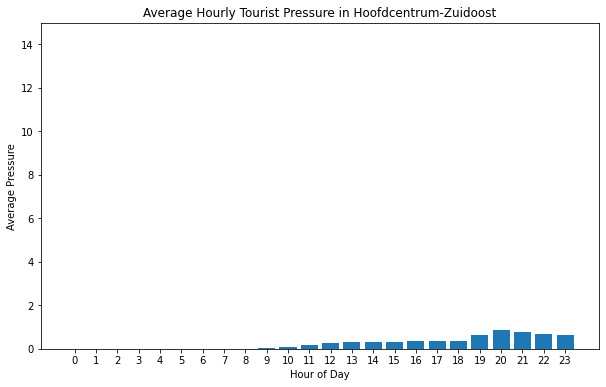

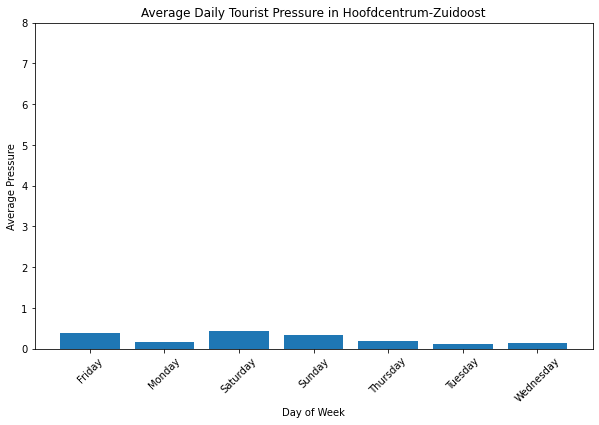

In [80]:
# Function to plot for a specific Wijk
def plot_for_wijk(selected_wijk):
    wijk_hourly_avg = hourly_press[hourly_press['Buurt'] == selected_wijk]
    wijk_daily_avg = daily_press[daily_press['Buurt'] == selected_wijk]
    
     # Hourly graph: Average hourly busyness (Bar chart)
    plt.figure(figsize=(10, 6))
    plt.bar(wijk_hourly_avg['Hour'], wijk_hourly_avg['pressure'])
    plt.title(f'Average Hourly Tourist Pressure in {selected_wijk}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Pressure')
    plt.xticks(range(0, 24))  # Ensure all hours are displayed
    plt.ylim(0, 15)
    plt.show()

    # Daily graph: Average daily busyness (Bar chart)
    plt.figure(figsize=(10, 6))
    plt.bar(wijk_daily_avg['Dayname'], wijk_daily_avg['pressure'])
    plt.title(f'Average Daily Tourist Pressure in {selected_wijk}')
    plt.xlabel('Day of Week')
    plt.ylabel('Average Pressure')
    plt.xticks(rotation=45)
    plt.ylim(0, 8)
    plt.show()

# Example usage: Replace 'Grachtengordel-West' with your desired neighborhood
selected_wijk = 'Hoofdcentrum-Zuidoost'
plot_for_wijk(selected_wijk)


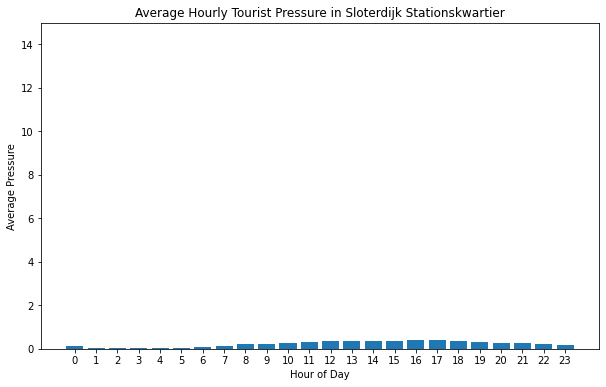

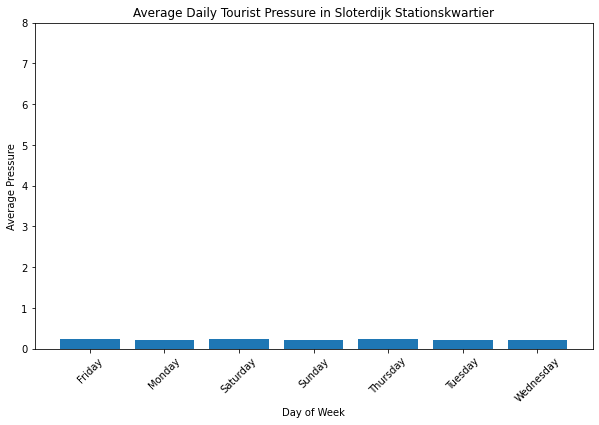

In [81]:
selected_wijk = 'Sloterdijk Stationskwartier'
plot_for_wijk(selected_wijk)


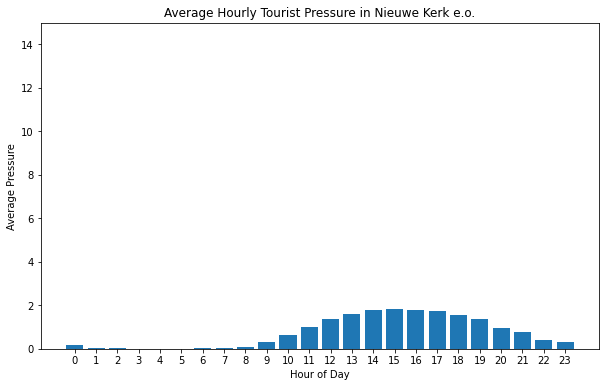

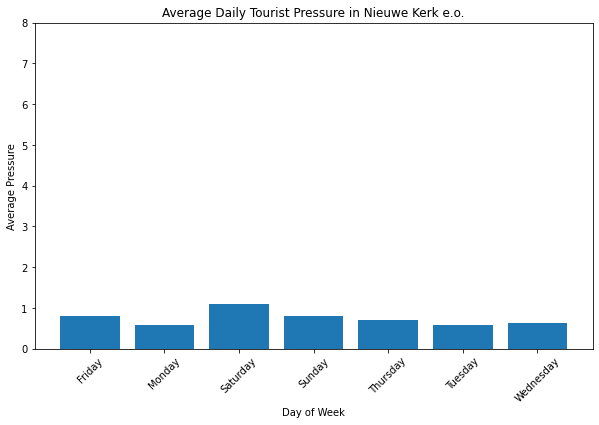

In [82]:
selected_wijk = 'Nieuwe Kerk e.o.'
plot_for_wijk(selected_wijk)

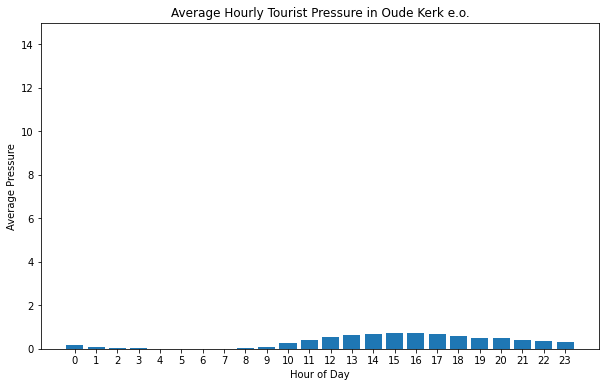

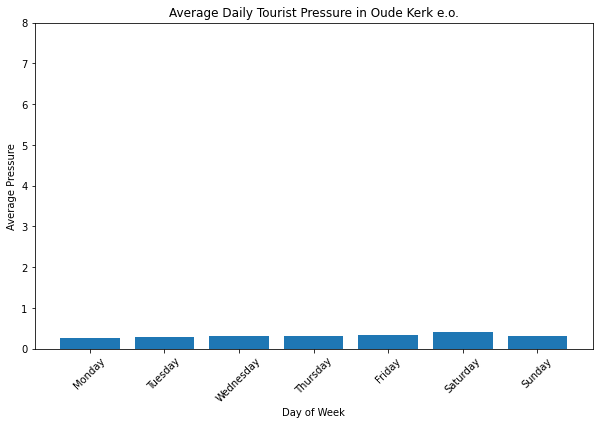

In [44]:
selected_wijk = 'Oude Kerk e.o.'
plot_for_wijk(selected_wijk)

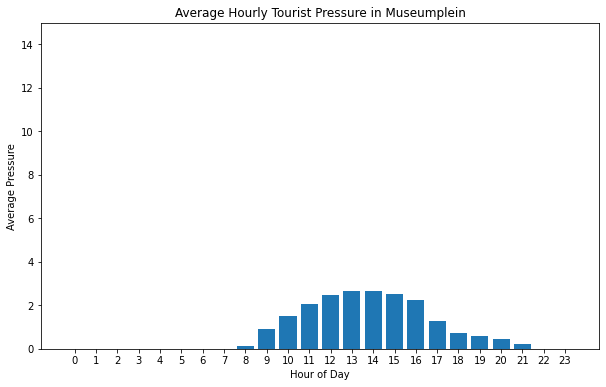

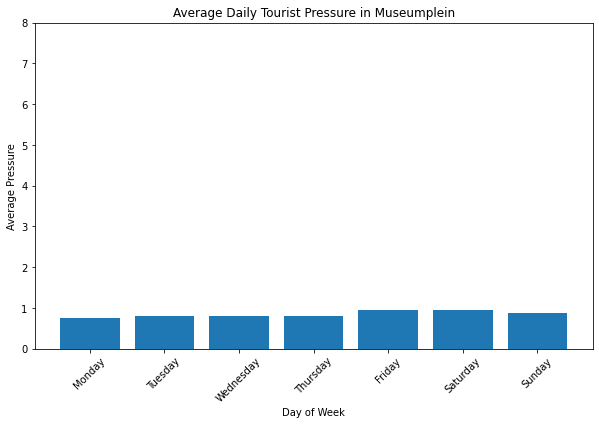

In [45]:
selected_wijk = 'Museumplein'
plot_for_wijk(selected_wijk)

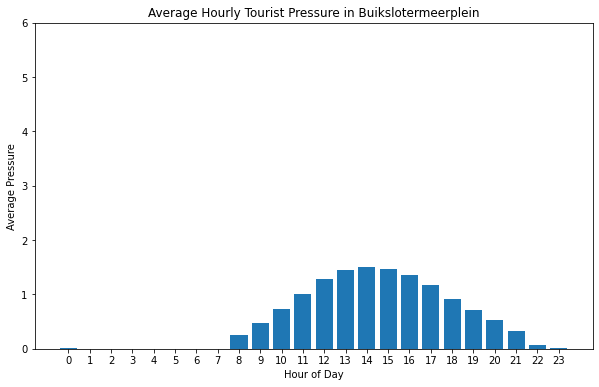

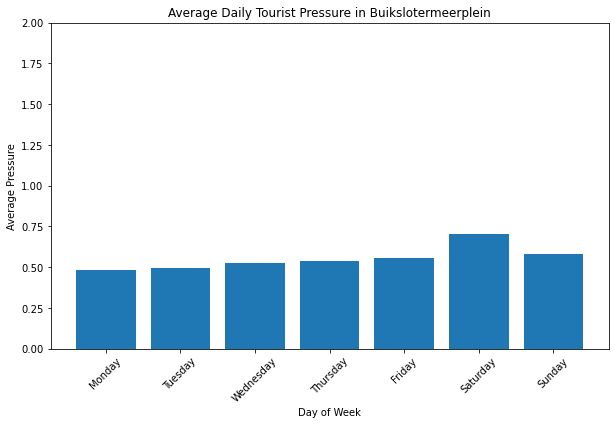

In [234]:
selected_wijk = 'Buikslotermeerplein'
plot_for_wijk(selected_wijk)

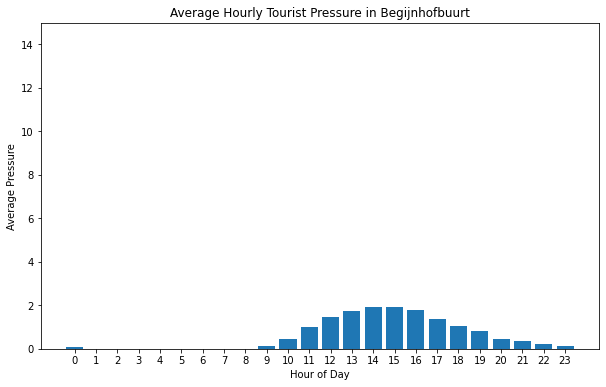

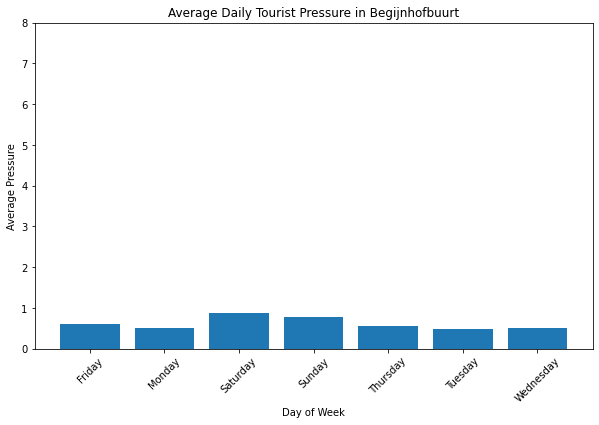

In [84]:
selected_wijk = 'Begijnhofbuurt'
plot_for_wijk(selected_wijk)

In [174]:
year = pd.read_csv("C:/Users/isamu/Downloads/82061NED_UntypedDataSet_09012025_161857.csv", delimiter = ";")
year = year[year["WoonlandVanGasten"] == "T001047"]
year = year[year["RegioS"] == "GM0363"]
year = year[year['Perioden'].str.contains('MM')]
year['datetime'] = pd.to_datetime(year['Perioden'].str[:4] + year['Perioden'].str[-2:], format='%Y%m')
year = year[year['datetime'].dt.year == 2023]
year['month'] = year['datetime'].dt.month # Extract just the month
year["Gasten_1"] = pd.to_numeric(year["Gasten_1"])
year

,ID,WoonlandVanGasten,RegioS,Perioden,Gasten_1,Overnachtingen_2,datetime,month
5178,5178,T001047,GM0363,2023MM01,593,1341,2023-01-01,1
5179,5179,T001047,GM0363,2023MM02,600,1369,2023-02-01,2
5180,5180,T001047,GM0363,2023MM03,709,1594,2023-03-01,3
5182,5182,T001047,GM0363,2023MM04,783,1855,2023-04-01,4
5183,5183,T001047,GM0363,2023MM05,786,1835,2023-05-01,5
5184,5184,T001047,GM0363,2023MM06,797,1842,2023-06-01,6
5186,5186,T001047,GM0363,2023MM07,930,2118,2023-07-01,7
5187,5187,T001047,GM0363,2023MM08,764,1896,2023-08-01,8
5188,5188,T001047,GM0363,2023MM09,705,1628,2023-09-01,9
5190,5190,T001047,GM0363,2023MM10,790,1826,2023-10-01,10


In [177]:
year["Gasten_1"] = (year["Gasten_1"] / year["Gasten_1"].sum()) * 100

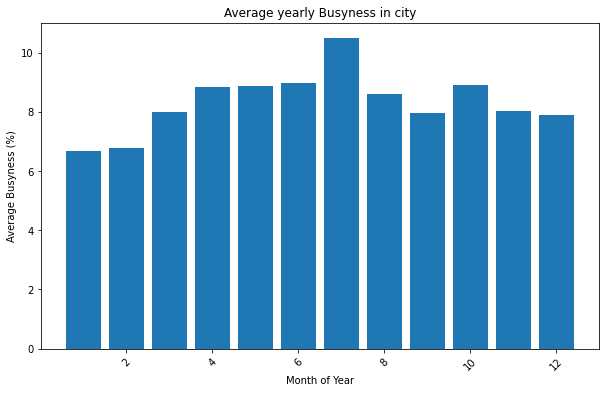

In [182]:
plt.figure(figsize=(10, 6))
plt.bar(year['month'], year["Gasten_1"])
plt.title(f'Average yearly Busyness in city')
plt.xlabel('Month of Year')
plt.ylabel('Average Busyness (%)')
plt.xticks(rotation=45)
plt.show()

In [83]:
reviews_per_year

,year,count
0,2006.0,6
1,2008.0,2
2,2009.0,4
3,2010.0,11
4,2011.0,192
5,2012.0,862
6,2013.0,1623
7,2014.0,4140
8,2015.0,7028
9,2016.0,19283


In [44]:
hotre

,year,count
0,2010.0,4
1,2011.0,22
2,2012.0,155
3,2013.0,334
4,2014.0,908
5,2015.0,1300
6,2016.0,2648
7,2017.0,14559
8,2018.0,50140
9,2019.0,81762


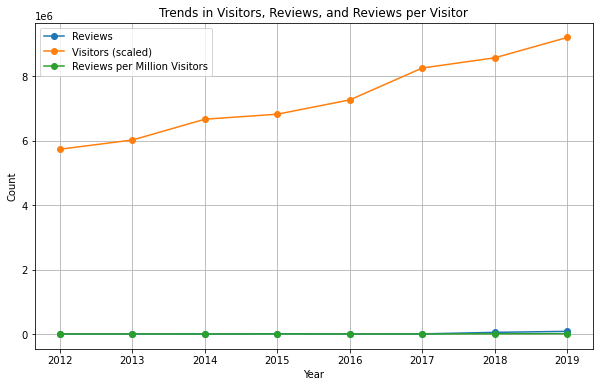

In [7]:
import matplotlib.pyplot as plt
# Data
data = {
    'year': [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
    'visitors': [5738000, 6024000, 6670000, 6826000, 7270000, 8260000, 8577000, 9209000],
    'reviews': [155, 334, 908, 7028, 1300, 2648, 50140, 81762]
}
df = pd.DataFrame(data)

# Calculate reviews per visitor
df['reviews_per_visitor'] = df['reviews'] / df['visitors']

# Plot
plt.figure(figsize=(10, 6))

# Plot reviews and visitors
plt.plot(df['year'], df['reviews'], label='Reviews', marker='o')
plt.plot(df['year'], df['visitors'], label='Visitors (scaled)', marker='o')

# Plot reviews per visitor (scaled for better visibility)
plt.plot(df['year'], df['reviews_per_visitor'] * 1e6, label='Reviews per Million Visitors', marker='o')

plt.title('Trends in Visitors, Reviews, and Reviews per Visitor')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

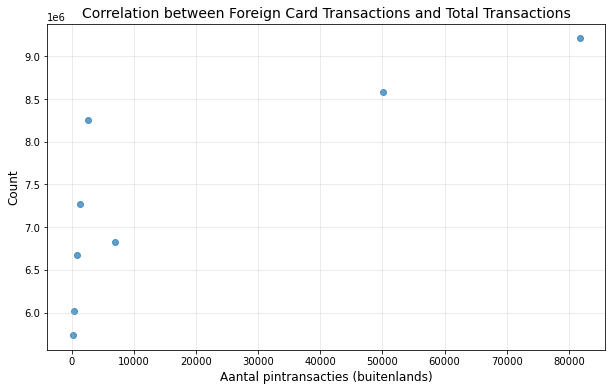

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df["reviews"], df["visitors"], alpha=0.7)
plt.title("Correlation between Foreign Card Transactions and Total Transactions", fontsize=14)
plt.xlabel("Aantal pintransacties (buitenlands)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

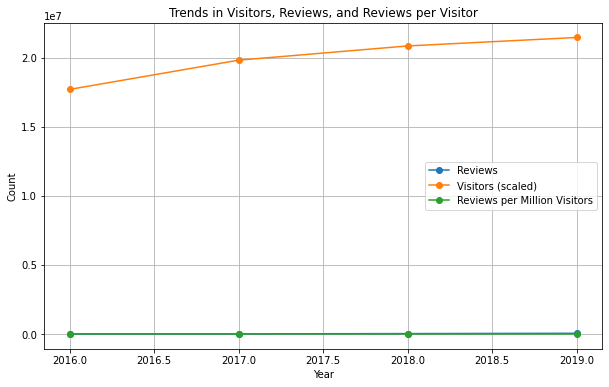

In [4]:
import matplotlib.pyplot as plt
# Data
data = {
    'year': [2016,2017,2018, 2019],
    'visitors': [17710000, 19828000, 20859000, 21472000],
    'reviews': [977, 7441, 27506, 49601]
}
df = pd.DataFrame(data)

# Calculate reviews per visitor
df['reviews_per_visitor'] = df['reviews'] / df['visitors']

# Plot
plt.figure(figsize=(10, 6))

# Plot reviews and visitors
plt.plot(df['year'], df['reviews'], label='Reviews', marker='o')
plt.plot(df['year'], df['visitors'], label='Visitors (scaled)', marker='o')

# Plot reviews per visitor (scaled for better visibility)
plt.plot(df['year'], df['reviews_per_visitor'] * 1e6, label='Reviews per Million Visitors', marker='o')

plt.title('Trends in Visitors, Reviews, and Reviews per Visitor')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

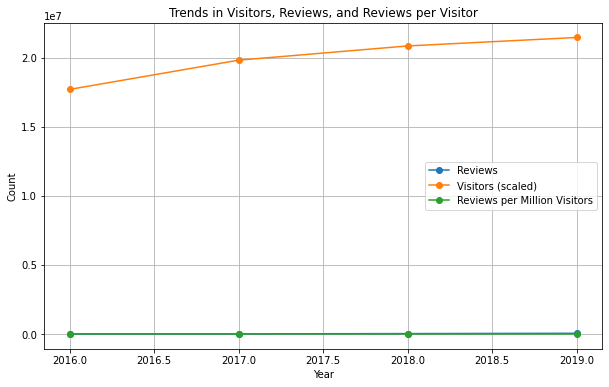

In [5]:
import matplotlib.pyplot as plt
# Data
data = {
    'year': [2016,2017,2018, 2019],
    'visitors': [17710000, 19828000, 20859000, 21472000],
    'reviews': [977, 7441, 27506, 49601]
}
df = pd.DataFrame(data)

# Calculate reviews per visitor
df['reviews_per_visitor'] = df['reviews'] / df['visitors']

# Plot
plt.figure(figsize=(10, 6))

# Plot reviews and visitors
plt.plot(df['year'], df['reviews'], label='Reviews', marker='o')
plt.plot(df['year'], df['visitors'], label='Visitors (scaled)', marker='o')

# Plot reviews per visitor (scaled for better visibility)
plt.plot(df['year'], df['reviews_per_visitor'] * 1e6, label='Reviews per Million Visitors', marker='o')

plt.title('Trends in Visitors, Reviews, and Reviews per Visitor')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

In [8]:
# Correlation between visitors and reviews
correlation_visitors_reviews = df['visitors'].corr(df['reviews'])

# Correlation between visitors and reviews per visitor
correlation_visitors_reviews_per_visitor = df['visitors'].corr(df['reviews_per_visitor'])

# Correlation between reviews and reviews per visitor
correlation_reviews_reviews_per_visitor = df['reviews'].corr(df['reviews_per_visitor'])

# Print the results
print(f"Correlation between visitors and reviews: {correlation_visitors_reviews:.2f}")
print(f"Correlation between visitors and reviews per visitor: {correlation_visitors_reviews_per_visitor:.2f}")
print(f"Correlation between reviews and reviews per visitor: {correlation_reviews_reviews_per_visitor:.2f}")


Correlation between visitors and reviews: 0.80
Correlation between visitors and reviews per visitor: 0.80
Correlation between reviews and reviews per visitor: 1.00
